# Emotion Annotation: Confusion Matrices (Human vs. LLM)

**Data:** `ablations/sample_emo_annot.csv` (100 posts)
- Column suffix `(L)` = LLM labels
- Column suffix `(R)` = Human Annotator A
- Column suffix `(G)` = Human Annotator B

For each annotator × emotion, we treat the **human label as ground truth**
and plot a 2×2 confusion matrix of the LLM predictions vs. the human labels,
together with Precision, Recall, and F1.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

df = pd.read_csv('../ablations/sample_emo_annot.csv')
print(f"Loaded {len(df)} annotated posts.")
print("Columns:", df.columns.tolist())

Loaded 100 annotated posts.
Columns: ['anger (L)', 'fear (L)', 'sad (L)', 'disgust (L)', 'anger (R)', 'fear (R)', 'sad (R)', 'disgust (R)', 'anger (G)', 'fear (G)', 'sad (G)', 'disgust (G)']


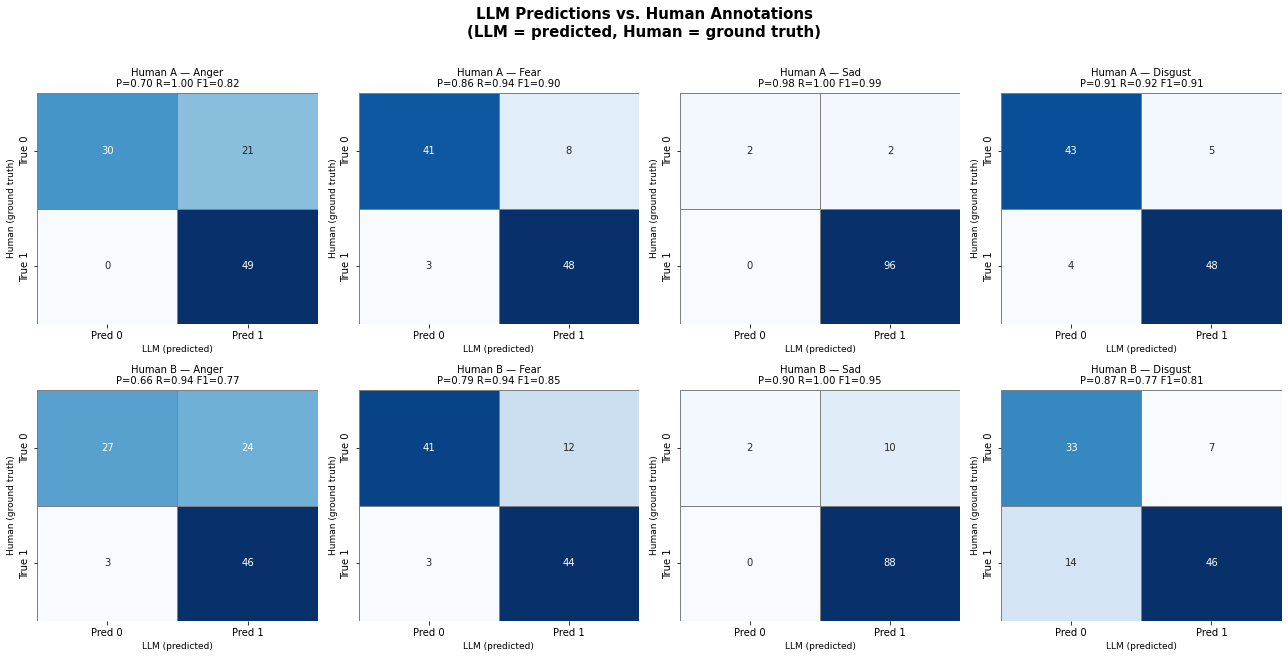

Saved to ablations/confusion_matrices.png


In [2]:
emotions = ['anger', 'fear', 'sad', 'disgust']
annotators = [('R', 'Human A'), ('G', 'Human B')]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('LLM Predictions vs. Human Annotations\n(LLM = predicted, Human = ground truth)',
             fontsize=15, fontweight='bold', y=1.01)

summary_rows = []

for row_idx, (suffix, annot_name) in enumerate(annotators):
    for col_idx, emo in enumerate(emotions):
        ax = axes[row_idx, col_idx]
        
        llm_col  = f'{emo} (L)'
        human_col = f'{emo} ({suffix})'
        
        y_true = df[human_col].values.astype(int)
        y_pred = df[llm_col].values.astype(int)
        
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        
        prec  = precision_score(y_true, y_pred, zero_division=0)
        rec   = recall_score(y_true, y_pred, zero_division=0)
        f1    = f1_score(y_true, y_pred, zero_division=0)
        acc   = np.mean(y_true == y_pred)
        
        summary_rows.append({
            'Annotator': annot_name,
            'Emotion': emo.capitalize(),
            'Precision': round(prec, 3),
            'Recall': round(rec, 3),
            'F1': round(f1, 3),
            'Accuracy': round(acc, 3),
        })
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred 0', 'Pred 1'],
                    yticklabels=['True 0', 'True 1'],
                    cbar=False, linewidths=0.5, linecolor='gray')
        
        ax.set_title(f'{annot_name} — {emo.capitalize()}\nP={prec:.2f} R={rec:.2f} F1={f1:.2f}',
                     fontsize=10)
        ax.set_xlabel('LLM (predicted)', fontsize=9)
        ax.set_ylabel('Human (ground truth)', fontsize=9)

plt.tight_layout()
plt.savefig('../ablations/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ablations/confusion_matrices.png")


In [3]:
summary_df = pd.DataFrame(summary_rows)
print("\n=== Summary Table: LLM vs Human Annotation Metrics ===")
print(summary_df.to_string(index=False))
print()
print("Average across emotions per annotator:")
print(summary_df.groupby('Annotator')[['Precision','Recall','F1','Accuracy']].mean().round(3))



=== Summary Table: LLM vs Human Annotation Metrics ===
Annotator Emotion  Precision  Recall    F1  Accuracy
  Human A   Anger      0.700   1.000 0.824      0.79
  Human A    Fear      0.857   0.941 0.897      0.89
  Human A     Sad      0.980   1.000 0.990      0.98
  Human A Disgust      0.906   0.923 0.914      0.91
  Human B   Anger      0.657   0.939 0.773      0.73
  Human B    Fear      0.786   0.936 0.854      0.85
  Human B     Sad      0.898   1.000 0.946      0.90
  Human B Disgust      0.868   0.767 0.814      0.79

Average across emotions per annotator:
           Precision  Recall     F1  Accuracy
Annotator                                    
Human A        0.861   0.966  0.906     0.893
Human B        0.802   0.910  0.847     0.818
